In [25]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter, find_peaks, peak_widths
import matplotlib.pyplot as plt
import json
# import simplekml
import math
import matplotlib.dates as mdates
import ee
# ee.Authenticate()
ee.Initialize(project="ee-joshisur231")
import geemap
Map = geemap.Map()
import plotly.graph_objects as go

In [26]:
# df = pd.read_csv(r"outputs/stable_ag_points_with_ndvi2000-2022_frtcOnly.csv")
df = pd.read_csv(r"outputs/test_range_crop.csv")
df["date"] = pd.to_datetime(df["time"], unit= "ms")
df = df.drop(columns=["time"])
# df = df[df["point_id"] == "000000000000000008e3"]

In [38]:
stable_cropland_ids = []
discarded_ids = []
ndvi_dict = {
    "point_id":[],
    "lc": [],
    "mean": [],
    "min": [],
    "max": [],
    "std":[]
}
grouped_points = df.sort_values(by="point_id").groupby("point_id")

for point_id, group in grouped_points:
    ts_raw = group.set_index('date')['NDVI'].resample("16D").mean()

    total_valid_obs = ts_raw.count()

    if total_valid_obs < 200:
        print(f"Insufficient Samples for {point_id}: total_valid_obs")
        discarded_ids.append(point_id)
        continue

    #Interpolate values across the entire 23 years
    ts_interp = ts_raw.interpolate(method="linear").bfill().ffill()

    # half_window = math.floor(year_valid_obs / 4) #timesat logic
    window = 11 #(2 * half_window) + 1
    
    smoothed_ndvi = savgol_filter(ts_interp.values, window_length = window, polyorder=2)
    smoothed_ndvi_series = pd.Series(smoothed_ndvi, index=ts_interp.index)

    peaks, properties = find_peaks(
        smoothed_ndvi, 
        height=0.35,         # Kept the same: reliably identifies active vegetation
        distance= 5,          # Lowered from 7: Allows peaks to be 80 days apart (Captures tight multi-cropping)
        width=(5, 15),       # Lowered from 7: 7 samples (80 days) captures the rapid Terai cycles, 15 caps the forests
        prominence=0.10      # Lowered from 0.12: Accounts for overlapping crop cycles where NDVI doesn't hit bare soil
    )
   
    peak_dates = ts_interp.index[peaks]

    yearly_classification = {}
    yearly_peaks = []

    for year in range(2000, 2023):
        smoothed_year = smoothed_ndvi_series[smoothed_ndvi_series.index.year == year]

        if len(smoothed_year) == 0:
            yearly_classification[year] = "insufficient_data"
            continue

        peaks_in_year = (peak_dates.year == year).sum()
        yearly_peaks.append(smoothed_year.max())

        if peaks_in_year >=1:
            yearly_classification[year] = "crop"
        else:
            yearly_classification[year] = "non_crop"
    
    overall_mean = smoothed_ndvi_series.mean()
    overall_min =  smoothed_ndvi_series.min()
    overall_max = smoothed_ndvi_series.max()

    std_max = np.std(yearly_peaks, ddof=1) if len(yearly_peaks) > 0 else 1.0

    total_non_crop = 0
    consecutive_non_crop = 0
    max_consecutive_non_crop = 0

    for year in range(2000, 2023):
        if yearly_classification.get(year) == "non_crop":
            total_non_crop += 1
            consecutive_non_crop += 1
            if consecutive_non_crop > max_consecutive_non_crop:
                max_consecutive_non_crop = consecutive_non_crop
        else:
            consecutive_non_crop = 0
    
    if total_non_crop >= 4 or max_consecutive_non_crop >= 3 or std_max > 0.112:
        discarded_ids.append(point_id)
        if std_max > 0.112:
            status_reason = "DISCARDED (Rangeland/High Variance)"
        else:
            status_reason = "DISCARDED (Failed Phenology)"
    else:
        stable_cropland_ids.append(point_id)
        status_reason = "STABLE CROPLAND"

    fig = go.Figure()
    # 2. Raw Resampled (Scatter Dots)
    fig.add_trace(go.Scatter(
        x=ts_raw.index, 
        y=ts_raw.values,
        mode='markers',
        name='Raw Resampled',
        marker=dict(color='grey', opacity=0.5),
        showlegend=True
    ))

    # 3. Raw Resampled (Dashed Connecting Line)
    fig.add_trace(go.Scatter(
        x=ts_raw.index, 
        y=ts_raw.values,
        mode='lines',
        name='Raw Resampled (Line)',
        line=dict(color='black', width=1, dash='dash'),
        opacity=0.6,
        showlegend=False # Matplotlib showed 1 legend item for both, this keeps it clean
    ))

    # 4. Savgol Smoothed (Solid Green Line)
    fig.add_trace(go.Scatter(
        x=ts_interp.index, 
        y=smoothed_ndvi,
        mode='lines',
        name='Savgol Smoothed',
        line=dict(color='green', width=1.5),
        opacity=0.7
    ))

    # 5. Detected Peaks (Red X Markers)
    if len(peaks) > 0:
        fig.add_trace(go.Scatter(
            x=ts_interp.index[peaks], 
            y=smoothed_ndvi[peaks],
            mode='markers',
            name='Detected Peaks',
            marker=dict(symbol='x', color='red', size=10, line=dict(width=2, color='red'))
        ))


    info_text = (
        f"Class: {group.iloc[0]['lc']}<br>"
        f"Mean, Min, Max: {round(overall_mean, 2)}, {round(overall_min, 2)}, {round(overall_max, 2)}<br>"
        f"Peak Std Dev: {std_max:.3f}<br>"
        f"Final Status: <b>{status_reason}</b><br>"
        f"Total Non-Crop Years: {total_non_crop}<br>"
        f"Max Consecutive Non-Crop: {max_consecutive_non_crop}<br>"
        f"Total Peaks (2000-2022): {len(peaks)}"
    )

    ndvi_dict["point_id"].append(point_id)
    ndvi_dict["lc"].append(group.iloc[0]["lc"])
    ndvi_dict["mean"].append(overall_mean)
    ndvi_dict["min"].append(overall_min)
    ndvi_dict["max"].append(overall_max)
    ndvi_dict["std"].append(std_max)

    fig.add_annotation(
        x=0.7,
        y=1.4,
        xref="paper",
        yref="paper",
        text=info_text,
        showarrow=False,
        align="left",
        bgcolor="rgba(255, 255, 255, 0.8)", # White background with 80% opacity
        bordercolor="gray",
        borderwidth=1,
        borderpad=6,
        font=dict(size=11),
        xanchor="left",
        yanchor="top"
    )

    # 7. Layout formatting (Mimicking Matplotlib styling)
    fig.update_layout(
        title=f"Continuous 23-Year Phenology Profile",
        height=450,           # Similar to figsize=(..., 5)
        plot_bgcolor='white', # Removes Plotly's default gray background
        
        # Y-Axis Settings (-0.1 to 1.0)
        yaxis=dict(
            range=[-0.1, 1.0], 
            gridcolor='rgba(128,128,128,0.2)', # Faint grid lines
            zerolinecolor='rgba(128,128,128,0.5)'
        ),
        
        # X-Axis Settings (1-year ticks, 45 degree angle)
        xaxis=dict(
            dtick="M12",          # Major ticks every 12 Months
            tickformat="%Y",      # Show only the Year
            tickangle=45,
            gridcolor='rgba(128,128,128,0.2)'
        ),
        
        # Legend position (Lower Right)
        legend=dict(
            x=0.99,
            y=0.02,
            xanchor="right",
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.7)"
        )
    )

    fig.show()

    
print(f"Total points analyzed: {len(grouped_points)}")
print(f"Pure Cropland Points Kept: {len(stable_cropland_ids)}")
print(f"Points Discarded: {len(discarded_ids)}")

Insufficient Samples for 1: total_valid_obs
Insufficient Samples for 2: total_valid_obs
Insufficient Samples for 3: total_valid_obs
Insufficient Samples for 4: total_valid_obs
Insufficient Samples for 5: total_valid_obs


Insufficient Samples for 8: total_valid_obs


Total points analyzed: 22
Pure Cropland Points Kept: 11
Points Discarded: 11


In [37]:
df.columns

Index(['system:index', 'NDVI', 'lc', 'point_id', '.geo', 'date', 'year'], dtype='object')

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# df = df.drop(columns = ['system:index', 'NDVI', 'lc', 'point_id', '.geo', 'date', 'year'])
df = pd.read_csv(r"outputs/test_range_crop.csv")
df["date"] = pd.to_datetime(df["time"], unit= "ms")
df = df.drop(columns=["time"])
df["year"] = df["date"].dt.year
df_group = df.drop(columns=["system:index", "point_id", ".geo", "date"]).groupby(by=["lc", "year"]).agg({"NDVI": "mean"}).reset_index()

<BarContainer object of 23 artists>

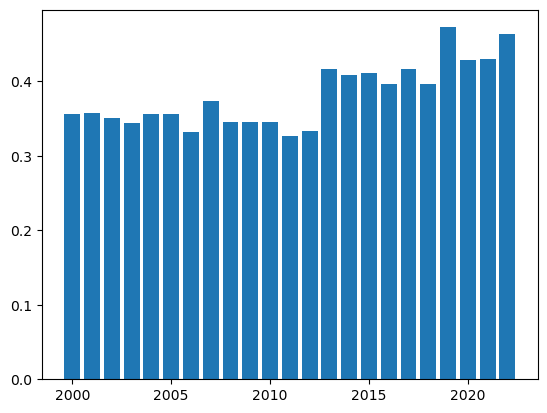

In [8]:
plt.bar(x=df_group[df_group["lc"] == "crop"].year, height= df_group[df_group["lc"] == "crop"].NDVI )

<BarContainer object of 23 artists>

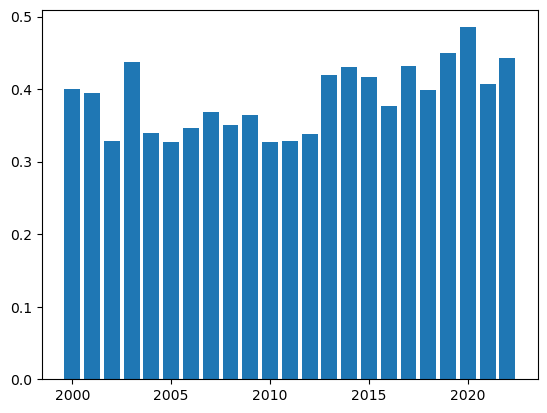

In [9]:
plt.bar(x=df_group[df_group["lc"] == "rangeland"].year, height= df_group[df_group["lc"] == "rangeland"].NDVI )

In [13]:
ndvi_df = pd.DataFrame(ndvi_dict)
ndvi_yearly = ndvi_df.groupby(by=["lc", "year"]).agg({})

In [29]:
ndvi_df

,point_id,lc,mean,min,max
0,6,rangeland,0.389664,0.139312,0.673415
1,7,rangeland,0.454434,0.279037,0.630958
2,9,rangeland,0.434196,0.248519,0.638127
3,10,rangeland,0.525485,0.274727,0.831256
4,11,rangeland,0.478484,0.295973,0.713768
5,12,crop,0.472832,0.221783,0.730187
6,13,crop,0.481773,0.154525,0.845774
7,14,crop,0.430195,0.288215,0.602089
8,15,crop,0.664327,0.488817,0.825862
9,16,crop,0.496106,0.348010,0.660821


crop


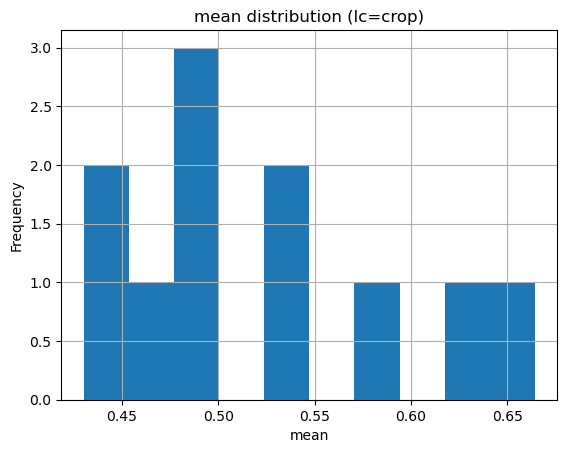

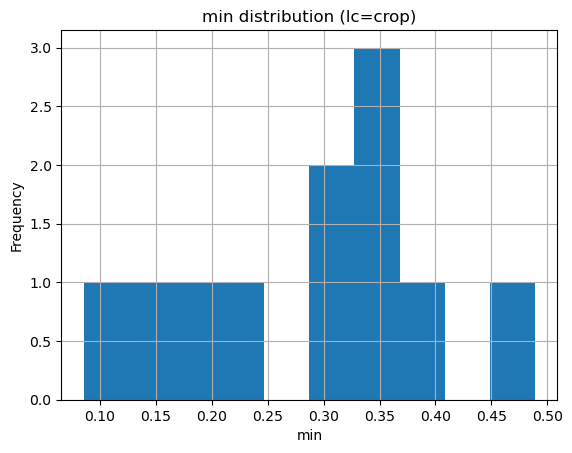

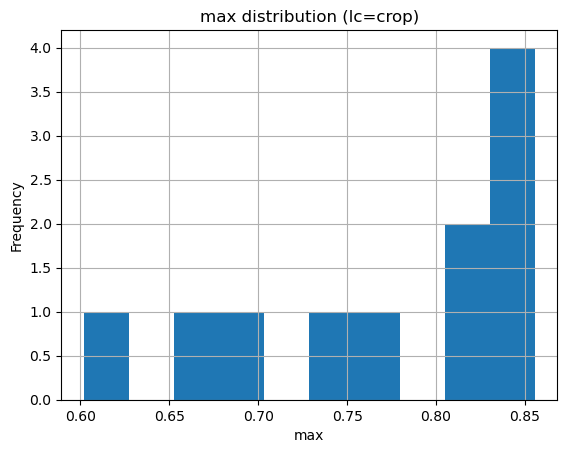

rangeland


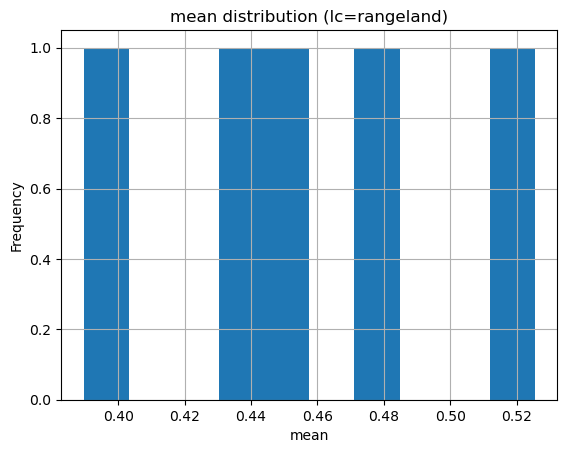

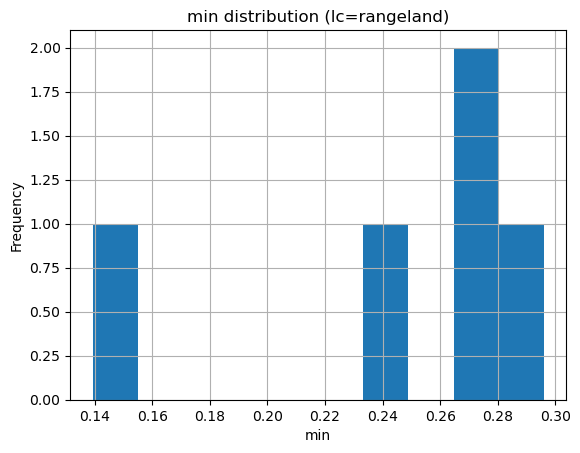

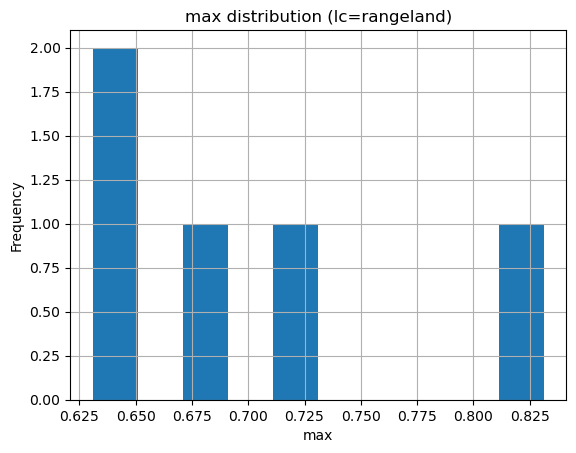

In [28]:
import matplotlib.pyplot as plt

for lc, group in ndvi_df.groupby("lc"):
    print(lc)
    # print(group.describe())

    for col in group.columns:
        if (col != "lc") & (col != "point_id"):  # skip grouping column
            plt.figure()  # new figure for each plot
            group[col].hist()
            plt.title(f"{col} distribution (lc={lc})")
            plt.xlabel(col)
            plt.ylabel("Frequency")
            plt.show()

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"outputs\phenology_verified_for_validation\final_stable_ag_manual_validation_samples_new.csv")
df = df[df["actual"]==1]
df["amp"] = df["max"] - df["min"]

In [3]:
df

,Unnamed: 0,geoReg,slope,orig_x,orig_y,mean,min,max,std,max_consecutive_non_crop,total_non_crop,total_peaks,status,point_id,actual,predicted,amp
1,1853,1,16.320841,86.123867,27.806049,0.4937,0.1790,0.8425,0.0777,1,2,25,STABLE CROPLAND,0000000000000000144c,1.0,1,0.6635
2,1834,1,5.578051,87.680735,27.309368,0.4814,0.1406,0.8342,0.0902,1,2,21,STABLE CROPLAND,00000000000000001420,1.0,1,0.6936
5,940,1,26.815863,81.938885,29.595763,0.5205,0.1846,0.8675,0.0615,0,0,23,STABLE CROPLAND,00000000000000000a67,1.0,1,0.6829
7,672,1,21.795383,87.666453,27.410968,0.4746,0.2148,0.7904,0.0884,0,0,24,STABLE CROPLAND,0000000000000000076e,1.0,1,0.5756
8,1042,1,20.109657,85.975646,27.617402,0.4123,0.1611,0.7440,0.0935,1,1,22,STABLE CROPLAND,00000000000000000ba2,1.0,1,0.5829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,1762,3,32.302219,84.605534,27.803623,0.5255,0.2007,0.8186,0.0818,1,1,22,STABLE CROPLAND,00000000000000001360,1.0,1,0.6179
169,1567,3,4.257287,81.622231,28.167709,0.3766,0.1474,0.7268,0.0978,1,3,22,STABLE CROPLAND,0000000000000000114c,1.0,1,0.5794
171,42,3,2.270254,87.513381,26.538612,0.4384,0.0947,0.8535,0.1171,1,1,22,STABLE CROPLAND,00000000000000000080,1.0,1,0.7588
172,466,3,29.500353,87.381597,26.845840,0.5617,0.1777,0.8596,0.0593,1,3,20,STABLE CROPLAND,0000000000000000053e,1.0,1,0.6819


In [4]:
df[["mean", "min", "max", "std", "amp"]].describe()

,mean,min,max,std,amp
count,141.000000,141.000000,141.000000,141.000000,141.000000
mean,0.442652,0.150866,0.817491,0.103460,0.666626
std,0.050625,0.048076,0.046782,0.022491,0.061192
min,0.334500,0.033000,0.696600,0.046200,0.552600
25%,0.408800,0.117900,0.783700,0.090000,0.624200
50%,0.441200,0.149500,0.823900,0.100100,0.663500
75%,0.479000,0.184200,0.853500,0.117900,0.705600
max,0.568100,0.249200,0.907100,0.164000,0.838800


<Axes: >

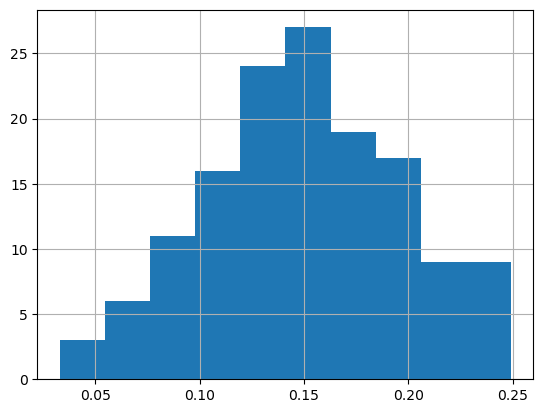

In [5]:
df["min"].hist()

In [20]:
import pandas as pd

In [22]:
df = pd.read_csv(r"E:\work\TISC_Vegetation_Classification\TISC_Veg_Classification_arcgisWS\temp\tisc_vegClass_district_area.csv")

In [23]:
val_col = ['VALUE_1', 'VALUE_2', 'VALUE_3', 'VALUE_4', 'VALUE_5', 'VALUE_6',
       'VALUE_7', 'VALUE_8', 'VALUE_9', 'VALUE_10', 'VALUE_11', 'VALUE_12',
       'VALUE_13', 'VALUE_14', 'VALUE_15', 'VALUE_16', 'VALUE_17', 'VALUE_18',
       'VALUE_19', 'VALUE_20', 'VALUE_21', 'VALUE_22', 'VALUE_23', 'VALUE_24',
       'VALUE_25', 'VALUE_26', 'VALUE_27', 'VALUE_28', 'VALUE_29', 'VALUE_30',
       'VALUE_31', 'VALUE_32', 'VALUE_33', 'VALUE_34', 'VALUE_35', 'VALUE_36',
       'VALUE_37', 'VALUE_38']

for col in val_col:
    new_col = col.replace("VALUE", "ha_value")
    df[new_col] = df[col]/10000
    df = df.drop(columns=[col])

In [24]:
df.to_csv(r"E:\work\TISC_Vegetation_Classification\tisc_vegClass_district_area.csv", index=False)

In [1]:
import geopandas as gpd

In [ ]:
gpd.read_file(r"E:\work\sdg\THA_adm1\THA_adm1.shp")

In [59]:
import pandas as pd
import geopandas as gpd
import ee 
ee.Initialize(project = "ee-joshisur231")
import geemap
Map = geemap.Map()
import ast

In [67]:
df = pd.read_csv(r"E:\work\Agricultural Land Abandonment\code\outputs\original_geometries_from_spatial_thinning_exported_fromGEE.csv")
# df = df[df["status"] == "STABLE CROPLAND"]
df["coords"] = df[".geo"].apply(lambda x: ast.literal_eval(x)["coordinates"])
df = df.drop(columns=[".geo"])
df["x"] = df["coords"].apply(lambda x: x[0])
df["y"] = df["coords"].apply(lambda x: x[1])
ee_df = geemap.df_to_ee(df, longitude="x", latitude="y")

In [68]:
ag_2003 = ee.ImageCollection("users/potapovpeter/Global_cropland_2003").first()
ag_2007 = ee.ImageCollection("users/potapovpeter/Global_cropland_2007").first()
ag_2011 = ee.ImageCollection("users/potapovpeter/Global_cropland_2011").first()
ag_2015 = ee.ImageCollection("users/potapovpeter/Global_cropland_2015").first()
ag_2019 = ee.ImageCollection("users/potapovpeter/Global_cropland_2019").first()

ag_stable = ag_2003.add(ag_2007).add(ag_2011).add(ag_2015).add(ag_2019).eq(5)

In [74]:
samples = ag_stable.reduceRegions(ee_df, scale=30, reducer=ee.Reducer.first())

In [76]:
samples.filter(ee.Filter.eq("first", 1)).size()

In [31]:
Map.addLayer(ag_stable.selfMask(), {"min":0, "max":1, "palette":["red"]}, "ag_stable")
Map

Map(bottom=54975.0, center=[28.567190136696055, 82.8165029863601], controls=(WidgetControl(options=['position'…